# 70B Block-Design Analysis — Recomputed runs/70b

Uses isolated-trial features recomputed from all folders in `runs/70b`, saved in
`dataNEW/70b`. E and N folders are paired by shared suffix; the unsuffixed folders
form the eighth pair. No fulltrace data is included.

Preserves the original notebook's single-feature clustering, 75% within-run
direction filter, Mann–Whitney tests, random-label checks, and prompt-subset
robustness sweeps. The four candidate throttle features are slope, variance, spectral entropy, and
mean rate. LZ complexity is omitted from extraction and analysis as requested.
Bonferroni correction covers features that pass the original direction filter.
Because that filter uses these data, corrected p-values are exploratory; the
pipeline does not account for feature selection or within-run dependence.
Clustering accuracy is an in-sample association measure, not held-out prediction.


## §1 — Imports and configuration

In [1]:
%matplotlib inline
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / 'dataNEW' / '70b').is_dir())
DATA_DIR   = BASE_DIR / 'dataNEW' / '70b'
RESULT_DIR = DATA_DIR / 'analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
RUNS = sorted(p.stem for p in DATA_DIR.glob('run*.csv'))

# ── indicators ─────────────────────────────────────────────────────────────
L1_INDICATORS = [
    #'hat_TLB',
    #'tlb:tlb_flush',
    'core_power.throttle',
]
# ── Analysis config ────────────────────────────────────────────────────────────
MAJORITY_THRESHOLD = 0.75
N_INIT             = 50
RAND_SEED          = 42
N_NULL_REPEATS     = 20

print('Configuration OK')
print(f'  Runs              : {RUNS}')
print(f'  Majority threshold: {MAJORITY_THRESHOLD:.0%}')
print(f'  Null repeats      : {N_NULL_REPEATS}')

CONDITIONS = ['emotional', 'neutral']
CODES = {'emotional': 'E', 'neutral': 'N', 'joyful': 'J'}
# Optional block-design CSVs outside DATA_DIR (not full-trace per-prompt CSVs).
EXTRA_BLOCK_CSVS = []

Configuration OK
  Runs              : ['run1', 'run2', 'run3', 'run4', 'run5', 'run6', 'run7', 'run_unsuffixed']
  Majority threshold: 75%
  Null repeats      : 20


## §2 — Load data

In [2]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'blocks{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

# Discover additional block CSVs, including new joy runs, in the same directory.
loaded_paths = {next(p for p in [DATA_DIR / f'blocks{r}.csv', DATA_DIR / f'{r}.csv'] if p.exists()).resolve()
                for r in runs_loaded}
for path in sorted(set(DATA_DIR.glob('*.csv')) | {Path(p) for p in EXTRA_BLOCK_CSVS}):
    if path.resolve() in loaded_paths or path.name.startswith('all_'):
        continue
    d = pd.read_csv(path)
    if not {'condition', 'prompt_index'}.issubset(d.columns):
        continue
    if 'mode' in d and d['mode'].isin(['per_prompt', 'whole_trace']).any():
        raise ValueError(f'{path} contains full-trace data, not block-design trials.')
    d['run'] = path.stem
    dfs.append(d)
    runs_loaded.append(path.stem)
    loaded_paths.add(path.resolve())
assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['condition'] = df_all['condition'].replace({'joy': 'joyful', 'independentJ': 'joyful'})
df_all['label'] = pd.Categorical(df_all.condition, categories=CONDITIONS).codes
if (df_all.label < 0).any():
    raise ValueError('Unexpected condition labels in block CSVs.')
ACTIVE_CONDITIONS = [c for c in CONDITIONS if (df_all.condition == c).any()]
PAIRS = list(combinations(ACTIVE_CONDITIONS, 2))
for cond in CONDITIONS:
    print(f'{cond.title()}: {(df_all.condition == cond).sum()} trials')
    if cond not in ACTIVE_CONDITIONS:
        print(f'  Missing {cond} block data: add its CSVs to DATA_DIR or EXTRA_BLOCK_CSVS.')
print(f'Loaded {len(runs_loaded)} runs, {len(df_all)} trials.')
assert len(runs_loaded) == 8 and len(df_all) == 320
assert not df_all.source_trial.duplicated().any()
assert df_all.groupby(['run', 'condition']).size().eq(20).all()
combined = pd.read_csv(DATA_DIR / 'all_trials.csv')
pd.testing.assert_frame_equal(
    df_all[combined.columns].sort_values('source_trial').reset_index(drop=True),
    combined.sort_values('source_trial').reset_index(drop=True))
print('Verified 320 unique trials, 20 per condition per run, and combined CSV agreement.')


Emotional: 160 trials
Neutral: 160 trials
Loaded 8 runs, 320 trials.
Verified 320 unique trials, 20 per condition per run, and combined CSV agreement.


## §3 — Select L1 features

In [3]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

requested_features = [f'core_power.throttle__{metric}' for metric in
                      ['slope', 'variance', 'spectral_entropy', 'mean_rate']]
# Do not impute an entirely unmeasured condition's feature (e.g. omitted LZ).
available_features = [f for f in requested_features if f in df_all and
                      all(df_all.loc[df_all.condition == c, f].notna().any() for c in ACTIVE_CONDITIONS)]
print('Unavailable features:', sorted(set(requested_features) - set(available_features)))
X_l1 = df_all[available_features].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]

print(f'L1 features available: {X_l1.shape[1]}')
print(f'Features: {list(X_l1.columns)}')
assert len(available_features) == 4
assert np.isfinite(df_all[available_features].to_numpy()).all(), 'Missing/nonfinite analysis features'


Unavailable features: []
L1 features available: 4
Features: ['core_power.throttle__slope', 'core_power.throttle__variance', 'core_power.throttle__spectral_entropy', 'core_power.throttle__mean_rate']


## §4 — Helper functions

In [4]:
def kmeans_acc_ari(X, y, n_init=N_INIT, seed=RAND_SEED):
    """K-means (k=2) with majority-vote alignment. Returns (accuracy, ARI)."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


def single_feature_sweep(X_feat_df, df, label_col='label', pair=('emotional', 'neutral')):
    """Single-feature sweep with per-run direction analysis and majority filter."""
    left, right = pair
    y_true = (df.condition == left).astype(int).values
    runs_unique = df['run'].unique()
    records = []
    for col in X_feat_df.columns:
        acc, ari = kmeans_acc_ari(X_feat_df[[col]].values, y_true)
        e_mean = X_feat_df.loc[df['condition'] == left, col].mean()
        n_mean = X_feat_df.loc[df['condition'] == right,   col].mean()
        direction = '↑' + CODES[left] if e_mean > n_mean else '↑' + CODES[right]
        
        run_dirs = []
        for run in runs_unique:
            mask_run = df['run'] == run
            e_run = X_feat_df.loc[mask_run & (df['condition'] == left), col].mean()
            n_run = X_feat_df.loc[mask_run & (df['condition'] == right),   col].mean()
            if not (np.isnan(e_run) or np.isnan(n_run)):
                run_dirs.append('↑' + CODES[left] if e_run > n_run else '↑' + CODES[right])
        
        n_majority = sum(1 for d in run_dirs if d == direction)
        n_valid    = len(run_dirs)
        maj_frac   = n_majority / n_valid if n_valid > 0 else 0.0
        
        records.append({
            'feature':       col,
            'accuracy':      acc,
            'ari':           ari,
            'direction':     direction,
            'runs_majority': f'{n_majority}/{n_valid}',
            'majority_frac': maj_frac,
        })
    return pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)


def mwu_bonferroni(X_feat_df, df, features, pair=('emotional', 'neutral')):
    """Mann-Whitney U with Bonferroni correction for a list of features."""
    left, right = pair
    if not len(features):
        return pd.DataFrame()
    records = []
    for feat in features:
        e = X_feat_df.loc[df.condition == left, feat].dropna()
        n = X_feat_df.loc[df.condition == right,   feat].dropna()
        u, p_raw = mannwhitneyu(e, n, alternative='two-sided')
        p_corr = min(p_raw * len(features), 1.0)
        records.append({
            'feature':     feat,
            'U':           u,
            'p_raw':       p_raw,
            'p_corrected': p_corr,
            'significant': 'YES' if p_corr < 0.05 else 'NO',
        })
    return pd.DataFrame(records)

print('Helpers defined.')

Helpers defined.


## §5 — Raw clustering (no residualisation)

In [5]:
pair_sweeps = {}
raw_tables, mwu_tables = [], []
for pair in PAIRS:
    mask = df_all.condition.isin(pair)
    sub, X_sub = df_all.loc[mask], X_l1.loc[mask]
    table = single_feature_sweep(X_sub, sub, pair=pair)
    table['pair'] = '–'.join(CODES[c] for c in pair)
    pair_sweeps[pair] = table
    raw_tables.append(table)
    passing = table.loc[table.majority_frac >= MAJORITY_THRESHOLD, 'feature'].tolist()
    tests = mwu_bonferroni(X_sub, sub, passing, pair=pair)
    if not tests.empty:
        tests['pair'] = table['pair'].iloc[0]
        mwu_tables.append(tests)
    print(table.to_string(index=False))
    if not passing:
        print('No features passed the per-run majority threshold for this pair.')
sf_raw = pd.concat(raw_tables, ignore_index=True).sort_values('accuracy', ascending=False)
sf_raw_filtered = sf_raw[sf_raw.majority_frac >= MAJORITY_THRESHOLD]
mwu_raw = pd.concat(mwu_tables, ignore_index=True) if mwu_tables else pd.DataFrame()
# Correct across every tested feature/pair combination.
if not mwu_raw.empty:
    mwu_raw['p_corrected'] = (mwu_raw.p_raw * len(mwu_raw)).clip(upper=1)
    mwu_raw['significant'] = np.where(mwu_raw.p_corrected < 0.05, 'YES', 'NO')
    print(mwu_raw.to_string(index=False))
sf_raw.to_csv(RESULT_DIR / 'single_feature_clustering.csv', index=False)
if mwu_raw.empty:
    mwu_raw = pd.DataFrame(columns=['feature', 'U', 'p_raw', 'p_corrected', 'significant', 'pair'])
    print('No MWU tests performed: no feature passed the 75% per-run direction filter.')
mwu_raw.to_csv(RESULT_DIR / 'mwu_tests.csv', index=False)


                              feature  accuracy       ari direction runs_majority  majority_frac pair
       core_power.throttle__mean_rate  0.546875  0.005942        ↑E           5/8          0.625  E–N
        core_power.throttle__variance  0.528125  0.000084        ↑N           4/8          0.500  E–N
core_power.throttle__spectral_entropy  0.512500 -0.002494        ↑N           5/8          0.625  E–N
           core_power.throttle__slope  0.506250 -0.002810        ↑E           5/8          0.625  E–N
No features passed the per-run majority threshold for this pair.
No MWU tests performed: no feature passed the 75% per-run direction filter.


## §8 — Null test: random labels within a single condition

Repeat the original balanced binary pseudo-label test within each available condition. The binary chance reference remains 50%; finite-sample label alignment can raise observed accuracy above it.

In [6]:
# Pick the best raw feature to test for spurious structure
NULL_FEATURE = sf_raw.iloc[0]['feature']
print(f'Null test feature: {NULL_FEATURE}')
print(f'(Testing whether clustering picks up structure with random labels)\n')

rng = np.random.default_rng(RAND_SEED)

null_records = []
for cond in ACTIVE_CONDITIONS:
    sub = df_all[df_all.condition == cond].copy().reset_index(drop=True)
    n_total = len(sub)
    X_sub = sub[[NULL_FEATURE]].fillna(sub[[NULL_FEATURE]].median()).values
    
    accs, aris = [], []
    for _ in range(N_NULL_REPEATS):
        # Assign exactly 50/50 random pseudo-labels
        pseudo = np.zeros(n_total, dtype=int)
        pseudo[:n_total // 2] = 1
        rng.shuffle(pseudo)
        
        if len(np.unique(pseudo)) < 2:
            continue
        
        acc, ari = kmeans_acc_ari(X_sub, pseudo)
        accs.append(acc)
        aris.append(ari)
    
    print(f'{cond:10s}  n={n_total:4d}  '
          f'mean_acc={np.mean(accs):.4f} ± {np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f} ± {np.std(aris):.4f}')

    null_records.append(dict(condition=cond, feature=NULL_FEATURE, mean_acc=np.mean(accs), std_acc=np.std(accs), mean_ari=np.mean(aris), std_ari=np.std(aris)))

pd.DataFrame(null_records).to_csv(RESULT_DIR / 'random_label_null.csv', index=False)

print(f'\nExpected: accuracy ≈ 0.50, ARI ≈ 0.00')
print(f'Repeats per condition: {N_NULL_REPEATS}')

Null test feature: core_power.throttle__mean_rate
(Testing whether clustering picks up structure with random labels)



emotional   n= 160  mean_acc=0.5187 ± 0.0179  mean_ARI=-0.0034 ± 0.0049


neutral     n= 160  mean_acc=0.5212 ± 0.0206  mean_ARI=-0.0018 ± 0.0050

Expected: accuracy ≈ 0.50, ARI ≈ 0.00
Repeats per condition: 20


## §9 — Summary

In [7]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)
print(f'Runs loaded          : {len(runs_loaded)}')
print(f'Total trials         : {len(df_all)}')
print(f'Features tested      : {X_l1.shape[1]}')
print()
print(f'Raw clustering — best feature      : {sf_raw.iloc[0].feature}')
print(f'                  accuracy         : {sf_raw.iloc[0].accuracy:.4f}')
print(f'                  ARI              : {sf_raw.iloc[0].ari:.4f}')
print(f'                  direction        : {sf_raw.iloc[0].direction} ({sf_raw.iloc[0].runs_majority})')
print()
print('Condition counts:', df_all.condition.value_counts().to_dict())
print('Best feature by condition pair:')
for pair, table in pair_sweeps.items():
    print(pair, table.iloc[0][['feature', 'accuracy', 'ari', 'runs_majority']].to_dict())

SUMMARY
Runs loaded          : 8
Total trials         : 320
Features tested      : 4

Raw clustering — best feature      : core_power.throttle__mean_rate
                  accuracy         : 0.5469
                  ARI              : 0.0059
                  direction        : ↑E (5/8)

Condition counts: {'emotional': 160, 'neutral': 160}
Best feature by condition pair:
('emotional', 'neutral') {'feature': 'core_power.throttle__mean_rate', 'accuracy': 0.546875, 'ari': 0.005941783927783943, 'runs_majority': '5/8'}


# ROB SWEEP

In [8]:
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS = 20

def robustness_sweep(feature, pair):
    rng = np.random.default_rng(RAND_SEED)
    left, right = pair
    pools = {c: df_all.loc[df_all.condition == c, 'prompt_index'].dropna().unique() for c in pair}
    records = []
    for x in SUBSET_SIZES:
        half = x // 2
        if half > min(len(v) for v in pools.values()):
            continue
        accs, aris, totals = [], [], []
        for _ in range(N_REPEATS):
            mask = pd.Series(False, index=df_all.index)
            for cond in pair:
                selected = rng.choice(pools[cond], size=half, replace=False)
                mask |= (df_all.condition == cond) & df_all.prompt_index.isin(selected)
            X_sub = X_l1.loc[mask, [feature]].values
            y_sub = (df_all.loc[mask, 'condition'] == left).astype(int).values
            acc, ari = kmeans_acc_ari(X_sub, y_sub)
            accs.append(acc); aris.append(ari); totals.append(mask.sum())
        records.append(dict(pair='–'.join(CODES[c] for c in pair), feature=feature, x=x,
                            total=np.mean(totals), mean_acc=np.mean(accs), std_acc=np.std(accs),
                            mean_ari=np.mean(aris), std_ari=np.std(aris)))
    return pd.DataFrame(records)

sweep_tables = []
for pair, table in pair_sweeps.items():
    best_feature = table.iloc[0]['feature']
    sweep = robustness_sweep(best_feature, pair)
    print(sweep.to_string(index=False))
    sweep_tables.append(sweep)
res = pd.concat(sweep_tables, ignore_index=True)
res.to_csv(RESULT_DIR / 'best_feature_robustness.csv', index=False)


pair                        feature  x  total  mean_acc  std_acc  mean_ari      std_ari
 E–N core_power.throttle__mean_rate 22  176.0  0.542898 0.034723  0.007086 1.527493e-02
 E–N core_power.throttle__mean_rate 24  192.0  0.545573 0.032479  0.007823 1.910233e-02
 E–N core_power.throttle__mean_rate 26  208.0  0.548077 0.023845  0.007224 1.068409e-02
 E–N core_power.throttle__mean_rate 28  224.0  0.545982 0.020365  0.006065 7.917795e-03
 E–N core_power.throttle__mean_rate 30  240.0  0.546250 0.023750  0.007081 9.629323e-03
 E–N core_power.throttle__mean_rate 32  256.0  0.542578 0.011581  0.004227 3.598962e-03
 E–N core_power.throttle__mean_rate 34  272.0  0.541176 0.015537  0.004428 6.133091e-03
 E–N core_power.throttle__mean_rate 36  288.0  0.546701 0.013514  0.006308 5.179284e-03
 E–N core_power.throttle__mean_rate 38  304.0  0.548520 0.009583  0.006800 3.734453e-03
 E–N core_power.throttle__mean_rate 40  320.0  0.546875 0.000000  0.005942 8.673617e-19


In [9]:
remaining_features = [f'core_power.throttle__{m}' for m in
                      ['variance', 'spectral_entropy']]
print('Robustness Sweep Summary for Table')
remaining_sweeps = []
for pair in PAIRS:
    for feature in remaining_features:
        if feature not in X_l1:
            continue
        sweep = robustness_sweep(feature, pair)
        if sweep.empty:
            continue
        remaining_sweeps.append(sweep)
        print(f'{pair}: {feature}')
        print(f'  Acc. range: {sweep.mean_acc.min():.3f} - {sweep.mean_acc.max():.3f}')
        print(f'  SD range: {sweep.std_acc.min():.3f} - {sweep.std_acc.max():.3f}')
if remaining_sweeps:
    pd.concat(remaining_sweeps, ignore_index=True).to_csv(RESULT_DIR / 'other_feature_robustness.csv', index=False)


Robustness Sweep Summary for Table


('emotional', 'neutral'): core_power.throttle__variance
  Acc. range: 0.520 - 0.541
  SD range: 0.000 - 0.027


('emotional', 'neutral'): core_power.throttle__spectral_entropy
  Acc. range: 0.512 - 0.547
  SD range: 0.000 - 0.027


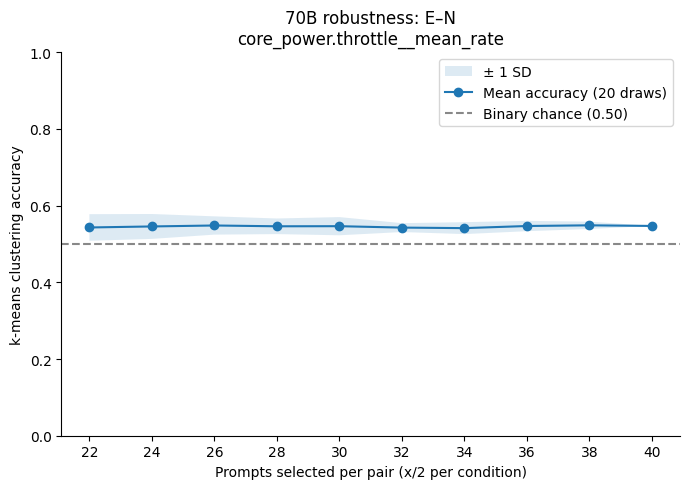

In [10]:
fig, axes = plt.subplots(1, len(PAIRS), figsize=(7 * len(PAIRS), 5), squeeze=False)
for ax, pair in zip(axes[0], PAIRS):
    pair_name = '–'.join(CODES[c] for c in pair)
    sub = res[res.pair == pair_name]
    if sub.empty:
        continue
    xs, mean, std = sub.x.to_numpy(), sub.mean_acc.to_numpy(), sub.std_acc.to_numpy()
    ax.fill_between(xs, mean-std, mean+std, alpha=0.15, label='± 1 SD')
    ax.plot(xs, mean, marker='o', label=f'Mean accuracy ({N_REPEATS} draws)')
    ax.axhline(0.5, color='#888888', ls='--', label='Binary chance (0.50)')
    ax.set_xlabel('Prompts selected per pair (x/2 per condition)')
    ax.set_ylabel('k-means clustering accuracy')
    ax.set_title(f'70B robustness: {pair_name}\n{sub.feature.iloc[0]}')
    ax.set_xticks(xs)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()